# Project: VisionWear AI
### Datum: 2026-06-06
### Teamleden: Michal Kakol (24087068), Sem Ooms (23091789), Chaimae Bouziani(21037078)

# 1. Setup:

Data voor deel 1 (data/Dataset/...):
Map Train (/Train/images/ and /Train/labels/):
Deze map bevat twee submappen, "images” en “labels”.
Train/images:
Deze map bevat 2145 foto's. Op elke foto staan één of meerdere kledingstukken of
modeaccessoires.
Train/labels:
Deze map bevat 2145 tekstbestanden, één voor elke afbeelding in de map Train/images.
- De naam van het tekstbestand (zonder de extensie) komt overeen met het
afbeeldingsbestand met dezelfde naam (zonder de extensie).
- Elke rij in het tekstbestand komt overeen met een item dat in het afbeeldingsbestand
moet worden gedetecteerd.
- De eerste kolom geeft de itemklasse weer. 0 = sunglass, 1 = hat, 2 = jacket, 3 = shirt, 4
= pants, 5 =shorts, 6 = skirt, 7 = dress, 8 = bag, 9 = shoe.
- De tweede en derde kolommen zijn de genormaliseerde x- en y-coördinaten van het
midden van de “bounding-box”. Om de coördinaten te normaliseren, nemen we
pixelwaarden van x en y, die het midden van de bounding-box op de x- en y-as
markeren. Vervolgens delen we de waarde van x door de breedte van de afbeelding
en de waarde van y door de hoogte van de afbeelding (in pixels).
- De laatste twee kolommen zijn de genormaliseerde breedte en de hoogte van de
bounding-box.
2
Map Test (Test/images/):
Deze map bevat alleen de submap "images".
Test/images:
Deze map bevat 537 foto's. Het getrainde model pas je toe op de foto's in deze map. De
voorspellingen die hieruit komen gebruik je om in te leveren op Kaggle. De voorspellingen
lever je in met een csv-bestand zoals submission_example.csv.
submission_example.csv:
De eerste kolom bevat de bestandsnamen ("id") van alle foto's in de map Test/images.
Nadat je je voorspellingen hebt gedaan plaats je deze in de kolom "predictions" van dit
bestand. Vervolgens kun je dit bestand uploaden op Kaggle.
De "predictions" kolom bevat de voorspelde annotaties voor elke afbeelding, weergegeven
als lijst. Elke voorspelling in de lijst bestaat uit verschillende componenten die betrekking
hebben op de gedetecteerde objecten in de afbeelding, met de volgende indeling:
- class_id: De voorspelde klasse-id voor het object (0 t/m 9).
- confidence: De betrouwbaarheidsscore van de detectie (0.0 t/m 1.0).
- center_x: De genormaliseerde x-coördinaat van het midden van de bounding-box
(0.0 t/m 1.0).
- center_y: De genormaliseerde y-coördinaat van het midden van de bounding-box
(0.0 t/m 1.0).
- width: De genormaliseerde breedte van de bounding-box (0.0 t/m 1.0).
- height: De genormaliseerde hoogte van de bounding-box (0.0 t/m 1.


Data voor deel 2 & 3:
De data voor deel 2 en 3 komen uit de H and M Fashion Caption 12k dataset. Je kunt deze
dataset rechtstreeks in je notebook gebruiken met behulp van de methode load_dataset().
Zorg ervoor dat je de nieuwste versie van de “datasets” library hebt geïnstalleerd en dat je
over een Hugging Face-account en een "access token" beschik

In [6]:
# ==========================================
# SETUP
# ==========================================

from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset


# ------------------------------------------
# Paths
# ------------------------------------------
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent

DATASET_DIR = Path("../data/Dataset").resolve()
TRAIN_IMAGES = DATASET_DIR / "Train" / "images"
TRAIN_LABELS = DATASET_DIR / "Train" / "labels"

TEST_IMAGES = DATASET_DIR / "Test" / "images"

print(TRAIN_IMAGES)
print(TRAIN_IMAGES.exists())

print(TRAIN_LABELS)
print(TRAIN_LABELS.exists())

print(TEST_IMAGES)
print(TEST_IMAGES.exists())


# ------------------------------------------
# Class mapping
# ------------------------------------------

CLASS_NAMES = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe"
}


# ------------------------------------------
# Basic checks
# ------------------------------------------

train_images = sorted(TRAIN_IMAGES.glob("*"))
train_labels = sorted(TRAIN_LABELS.glob("*.txt"))
test_images = sorted(TEST_IMAGES.glob("*"))

print(f"Train images : {len(train_images)}")
print(f"Train labels : {len(train_labels)}")
print(f"Test images  : {len(test_images)}")

assert len(train_images) == len(train_labels), \
    "Mismatch between train images and labels."


# ------------------------------------------
# Hugging Face dataset
# ------------------------------------------
# Uncomment once you have access

hm_dataset = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")

print(hm_dataset)

C:\Users\mkako\Portables\Projects\VisionWear-AI\data\Dataset\Train\images
True
C:\Users\mkako\Portables\Projects\VisionWear-AI\data\Dataset\Train\labels
True
C:\Users\mkako\Portables\Projects\VisionWear-AI\data\Dataset\Test\images
True
Train images : 2145
Train labels : 2145
Test images  : 537
DatasetDict({
    train: Dataset({
        features: ['text', 'image'],
        num_rows: 12437
    })
})


# 2. EDA:


The object detection dataset contains 2,145 training images, 2,145 label files, and 537 test images. A total of 8,298 annotated fashion objects are present in the training set. On average, each image contains 3.87 objects, with most images containing between 3 and 5 items. The maximum number of annotated objects in a single image is 7.

Visual inspection of randomly selected images confirmed that the YOLO annotations are correctly aligned with the fashion items in the images. The displayed bounding boxes accurately surround the corresponding clothing items and accessories, indicating that the label format was interpreted correctly and no obvious annotation issues were observed during inspection.

The dataset contains ten classes: sunglass, hat, jacket, shirt, pants, shorts, skirt, dress, bag, and shoe. The class distribution is not perfectly balanced. Shoe is the most common class (approximately 25% of all annotations), followed by shirt (17.8%) and bag (14.3%). Hat and sunglass are the least represented classes, accounting for approximately 3.3% and 4.1% of the annotations respectively. Although a class imbalance exists, all classes are represented by several hundred examples, providing sufficient training samples for each category.

Analysis of the bounding box dimensions shows that most objects occupy a relatively small to medium portion of the image. The average normalized bounding box width is 0.253 and the average height is 0.212. The average bounding box area is 0.063, while the median area is 0.045. Most objects therefore cover less than 10% of the image area. Very large objects are uncommon, with the largest bounding box occupying approximately 46% of the image. The distributions indicate that the dataset mainly contains localized fashion items rather than objects filling the entire image.

All images have the same resolution of 400 × 600 pixels. No variation in image dimensions was observed. This results in a highly consistent dataset where every sample shares the same aspect ratio and image size. Such consistency simplifies preprocessing and removes the need to handle multiple image resolutions during model training.

The H&M Fashion Caption dataset contains 12,437 image-caption pairs. To evaluate the relationship between the captioning dataset and the object detection dataset, the occurrence of the detection classes was searched within the caption texts. The most frequently occurring fashion terms were dress, shirt, and skirt. Jacket, hat, and shorts also appeared regularly. In contrast, bag appeared infrequently, while pants, shoe, and sunglass were almost absent when searched using the exact class names.

These results suggest that the object detection and captioning datasets share several important fashion concepts, particularly for upper-body clothing and dresses. However, some detection classes may appear in the captions under alternative wording or synonyms rather than the exact class names used in the detection dataset. Consequently, direct keyword frequency should be interpreted as an indicator of overlap rather than a complete representation of the semantic coverage of the caption dataset.

Overall, the datasets are well aligned with the project objective of detecting fashion items and generating textual descriptions. The detection dataset provides structured object-level annotations for ten fashion categories, while the H&M dataset provides natural language descriptions of fashion products. Together they form a suitable foundation for building a pipeline that combines object detection, image captioning, and fashion image generation.

Images: 2145
Labels: 2145
Objects: 8298
Objects per image:
count    2145.000000
mean        3.868531
std         0.977576
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
dtype: float64


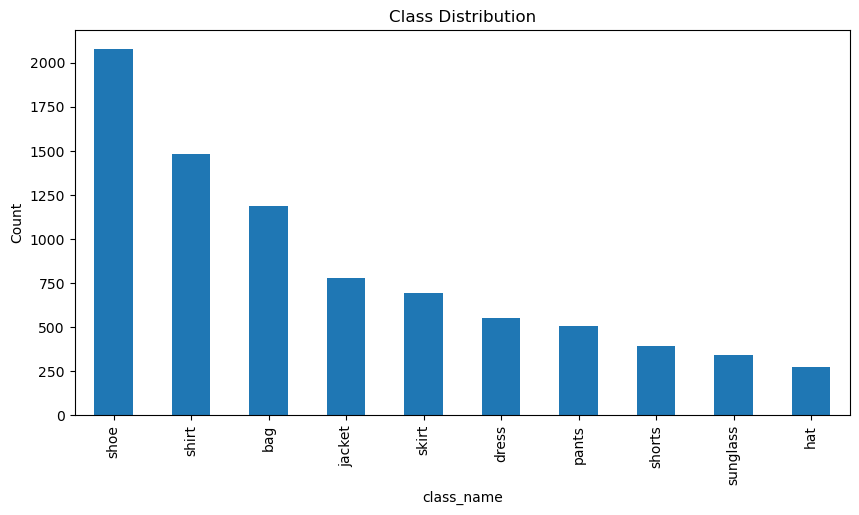

            count  percentage
class_name                   
shoe         2081       25.08
shirt        1486       17.91
bag          1188       14.32
jacket        777        9.36
skirt         697        8.40
dress         550        6.63
pants         508        6.12
shorts        395        4.76
sunglass      343        4.13
hat           273        3.29


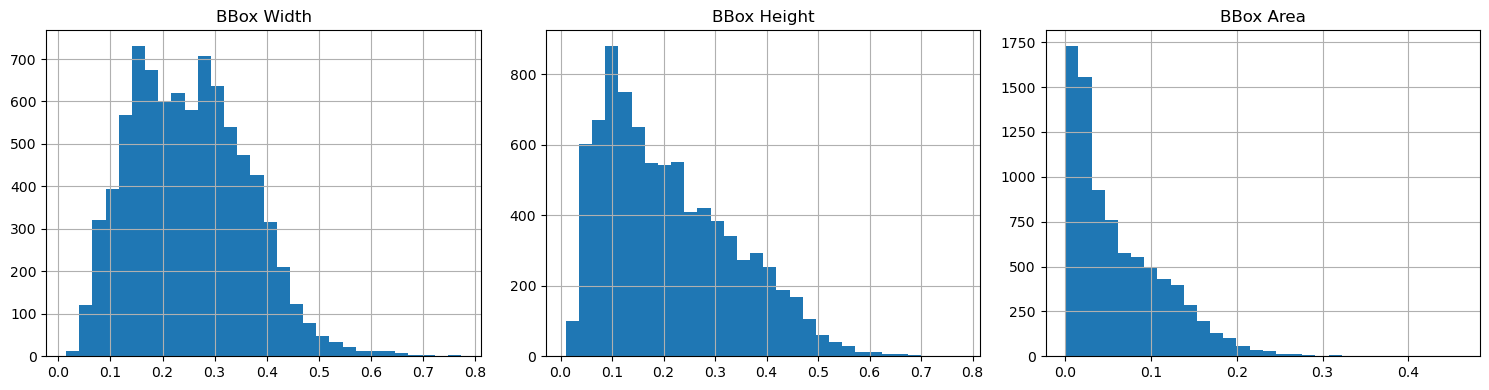

             width       height         area
count  8298.000000  8298.000000  8298.000000
mean      0.252748     0.211808     0.062582
std       0.111025     0.127133     0.055055
min       0.015000     0.010000     0.000225
25%       0.162500     0.108333     0.018333
50%       0.245000     0.186667     0.045046
75%       0.330000     0.298333     0.095850
max       0.772500     0.776667     0.460350
        width  height
count  2145.0  2145.0
mean    400.0   600.0
std       0.0     0.0
min     400.0   600.0
25%     400.0   600.0
50%     400.0   600.0
75%     400.0   600.0
max     400.0   600.0


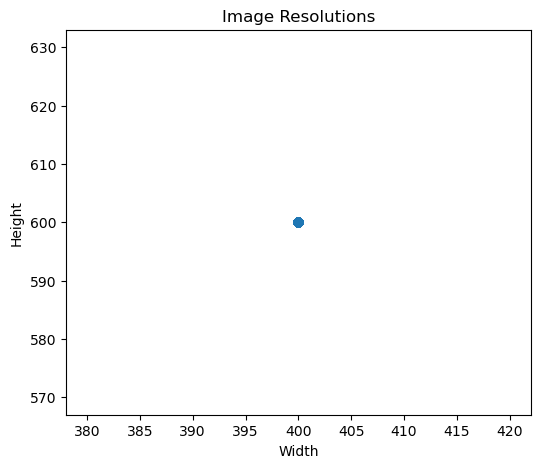

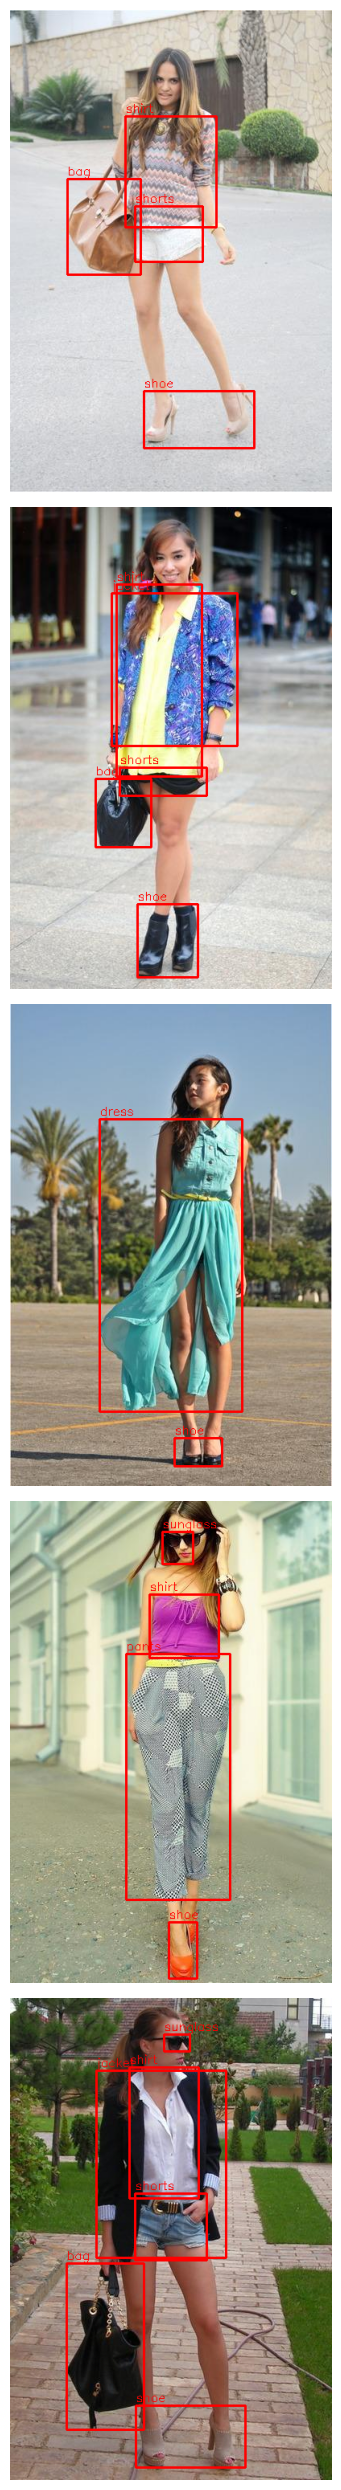

,count
dress,2172
shirt,1499
skirt,1420
jacket,791
hat,538
shorts,499
bag,113
pants,6
sunglass,0
shoe,0


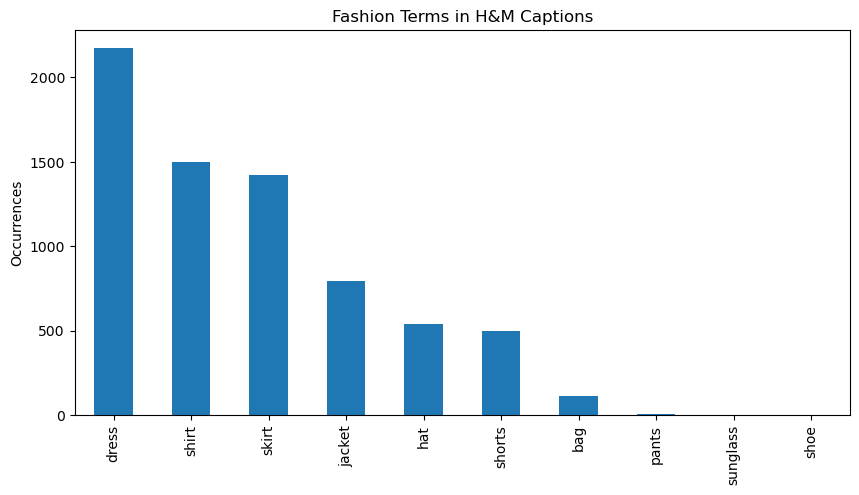

In [10]:
class FashionEDA:
    def __init__(self,
                 image_dir,
                 label_dir,
                 class_names):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.class_names = class_names
        self.images = sorted(self.image_dir.glob("*"))
        self.labels = sorted(self.label_dir.glob("*.txt"))
        self.annotations = self._load_annotations()

    def _load_annotations(self):
        rows = []
        for label_file in self.labels:
            image_name = label_file.stem
            with open(label_file, "r") as f:
                for line in f:
                    values = line.strip().split()
                    if len(values) != 5:
                        continue
                    cls, cx, cy, w, h = map(float, values)
                    rows.append({
                        "image": image_name,
                        "class_id": int(cls),
                        "class_name": self.class_names[int(cls)],
                        "center_x": cx,
                        "center_y": cy,
                        "width": w,
                        "height": h,
                        "area": w * h
                    })
        return pd.DataFrame(rows)

    # Dataset overview
    def dataset_summary(self):
        print(f"Images: {len(self.images)}")
        print(f"Labels: {len(self.labels)}")
        print(f"Objects: {len(self.annotations)}")
        print("Objects per image:")
        print(
            self.annotations.groupby("image").size().describe())

    # Class distribution
    def class_distribution(self):
        counts = (
            self.annotations["class_name"]
            .value_counts()
            .sort_values(ascending=False)
        )
        plt.figure(figsize=(10, 5))
        counts.plot(kind="bar")
        plt.title("Class Distribution")
        plt.ylabel("Count")
        plt.show()
        return counts

    # Bounding box size analysis
    def bbox_analysis(self):
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        self.annotations["width"].hist(ax=ax[0], bins=30)
        ax[0].set_title("BBox Width")
        self.annotations["height"].hist(ax=ax[1], bins=30)
        ax[1].set_title("BBox Height")
        self.annotations["area"].hist(ax=ax[2], bins=30)
        ax[2].set_title("BBox Area")
        plt.tight_layout()
        plt.show()
        print(self.annotations[["width", "height", "area"]].describe())

    # Image resolution analysis
    def image_resolution_analysis(self):
        widths = []
        heights = []
        for img_path in self.images:
            img = cv2.imread(str(img_path))
            h, w = img.shape[:2]
            widths.append(w)
            heights.append(h)
        df = pd.DataFrame({"width": widths, "height": heights})
        print(df.describe())
        plt.figure(figsize=(6, 5))
        plt.scatter(df["width"], df["height"], alpha=0.4)
        plt.xlabel("Width")
        plt.ylabel("Height")
        plt.title("Image Resolutions")
        plt.show()

    def class_balance_report(self):

        counts = (
            self.annotations["class_name"]
            .value_counts()
            .sort_values(ascending=False)
        )

        percentages = (
            counts / counts.sum() * 100
        ).round(2)

        report = pd.DataFrame({
            "count": counts,
            "percentage": percentages
        })

        print(report)

        return report

    # Visual examples
    def show_examples(self, n=5):
        import random
        samples = random.sample(self.images, n)
        fig, axes = plt.subplots(n, 1, figsize=(8, n * 5))
        if n == 1:
            axes = [axes]
        for ax, img_path in zip(axes, samples):
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            label_file = (self.label_dir / f"{img_path.stem}.txt")
            with open(label_file) as f:
                for line in f:
                    cls, cx, cy, bw, bh = map(float, line.split())
                    x1 = int((cx - bw / 2) * w)
                    y1 = int((cy - bh / 2) * h)
                    x2 = int((cx + bw / 2) * w)
                    y2 = int((cy + bh / 2) * h)
                    cv2.rectangle(
                        img,
                        (x1, y1),
                        (x2, y2),
                        (255, 0, 0),
                        2
                    )
                    cv2.putText(
                        img,
                        self.class_names[int(cls)],
                        (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255, 0, 0),
                        1
                    )
            ax.imshow(img)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

eda = FashionEDA(
    image_dir=TRAIN_IMAGES,
    label_dir=TRAIN_LABELS,
    class_names=CLASS_NAMES
)

eda.dataset_summary()

eda.class_distribution()

eda.class_balance_report()

eda.bbox_analysis()

eda.image_resolution_analysis()

eda.show_examples(5)

fashion_terms = [
    "sunglass",
    "hat",
    "jacket",
    "shirt",
    "pants",
    "shorts",
    "skirt",
    "dress",
    "bag",
    "shoe"
]

captions = [text.lower() for text in hm_dataset["train"]["text"]]

term_counts = {}

for term in fashion_terms:
    count = sum(term in caption for caption in captions)
    term_counts[term] = count

term_df = (
    pd.DataFrame.from_dict(
        term_counts,
        orient="index",
        columns=["count"]
    )
    .sort_values("count", ascending=False)
)

display(term_df)

term_df.plot(
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Fashion Terms in H&M Captions"
)

plt.ylabel("Occurrences")
plt.show()


# 3. Objectdetectie:

1. School Criteria & Grading Requirements

    Deliverable: Build, preprocess, and train an object detection model tracking 10 distinct fashion classes.

    Performance Threshold: Must achieve a Mean Average Precision (mAP) of ≥ 0.7 (70%) at an Intersection over Union (IoU) threshold of 0.5 on Kaggle.

    Required Explanations: Written walkthroughs explaining:

        How the model makes predictions in your own words.

        Image preprocessing and feature engineering steps.

        Hyperparameter selection (Optimizer, Learning Rate, Epochs, Batch Size).

        The exact mechanics of the loss function.

2. Strategic EDA Alignment

    Fixed Dimension Optimization: The EDA reveals that all images are uniformly 400×600 pixels. Preprocessing will preserve this clean aspect ratio or normalize inputs via letterboxing to standard dimensions (640×640).

    Small Object Adaptation: Over 50% of your targets are highly localized, occupying less than 10% of the total canvas area. The model must utilize a fine feature grid or dense anchor scales to avoid missing small targets like sunglasses (4.1%) or hats (3.3%).

    Class Imbalance Resolution: Shoes constitute 25% of all annotations, while hats constitute only 3.3%. We will counter this during training via data augmentation or balanced batching to ensure minority classes are not suppressed.

3. Technical Architecture & Theoretical Justification

[Input Image: 640x640] ➔ [Single Pass CNN Backbone] ➔ [Grid-Based Anchor Adjustment] ➔ [Non-Max Suppression (NMS)] ➔ [Final Box + Class]

    Model Framework: YOLOv8 / YOLOv11 (Ultralytics). This matches the 80/20 rule perfectly. The project data is already structured in standard YOLO text format (class_id center_x center_y width height normalized between 0.0 and 1.0). Forcing custom object detectors via raw TensorFlow layers here creates unnecessary complexity.

    Prediction Mechanics: YOLO maps the input image onto an N×N grid structure. Each cell evaluates a set of predefined Anchor Boxes, calculating offset adjustments instead of creating raw boxes from scratch. The network outputs an efficient array shape of:
    Shape=(N×N)×(B×(5+C))

    Where B represents anchor variants, C represents the 10 target classes, and 5 covers coordinates (x,y,w,h) plus the absolute objectness confidence score.

    Post-Processing: Multi-object over-detections are pruned using Non-Max Suppression (NMS). NMS evaluates predictions, sorts them by confidence, and removes surrounding boxes that exceed an IoU overlap threshold of 0.5:
    IoU=Area of UnionArea of Intersection​

    Loss Function Setup: A multi-task loss combining:

        Bounding Box Regression Loss: Complete Intersection over Union (CIoU) to optimize bounding box overlaps.

        Objectness Loss: Binary Cross-Entropy (BCE) to determine if a fashion item exists in a grid cell.

        Classification Loss: Binary Cross-Entropy (BCE) tracking multi-class probability scores across the 10 item categories.

In [2]:
import os
from ultralytics import YOLO

# 1. Hyperparameter Configuration (80/20 Rule Optimization)
CONFIG = {
    "model_type": "yolov8n.pt",  # Lightweight Nano variant for fast training/high mAP
    "epochs": 30,                # Sufficient for convergence on 2,145 samples
    "batch_size": 16,            # Memory safe default
    "imgsz": 640,                # Automatic scaling step
    "optimizer": "AdamW",        # Advanced weight decay optimization
    "lr0": 1e-3                  # Stable initial learning rate
}

# 2. Coordinates Helper Functions for Explanations
def yolo_to_corners(x_center, y_center, width, height):
    """Converts normalized center points to corner pixel coordinates."""
    x_min = x_center - (width / 2)
    y_min = y_center - (height / 2)
    x_max = x_center + (width / 2)
    y_max = y_center + (height / 2)
    return x_min, y_min, x_max, y_max

# 3. Model Definition and Execution Pipeline
def train_object_detector():
    # Load pre-trained weights to leverage pre-learned visual features
    model = YOLO(CONFIG["model_type"])

    # Train using custom dataset configuration file (dataset.yaml)
    results = model.train(
        data="dataset.yaml",
        epochs=CONFIG["epochs"],
        batch=CONFIG["batch_size"],
        imgsz=CONFIG["imgsz"],
        optimizer=CONFIG["optimizer"],
        lr0=CONFIG["lr0"],
        device="0" # Utilizes GPU acceleration
    )
    return model

# 4. Inference & Kaggle Submission Generator Format
def generate_kaggle_submission(model, test_images_dir, sample_csv_path):
    import pandas as pd
    df = pd.read_csv(sample_csv_path)
    predictions_list = []

    for img_id in df['id']:
        img_path = os.path.join(test_images_dir, img_id)
        outputs = model.predict(img_path, conf=0.25)[0]

        img_preds = []
        for box in outputs.boxes:
            # Extract normalized outputs matching template criteria
            cls_id = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            xywhn = box.xywhn[0].tolist() # [x_center, y_center, width, height]
            img_preds.extend([cls_id, conf] + xywhn)

        predictions_list.append(str(img_preds))

    df['predictions'] = predictions_list
    df.to_csv("final_submission.csv", index=False)

# 4. Ondertiteling van afbeeldinge:

1. School Criteria & Grading Requirements

    Deliverable: Fine-tune an image-to-text language model on the H and M Fashion Caption 12k dataset.

    Required Explanations: Written walkthroughs explaining:

        The core visual-to-linguistic prediction architecture.

        The exact mathematical optimization via the loss function.

        Methodological justification for hyperparameter bounds and optimization targets.

    Evaluation Metric: Use the BLEU Score to evaluate your predictions against the ground-truth product descriptions.

2. Strategic EDA Alignment

    Semantic Matching Rule: The EDA indicates that terms like dress, shirt, and skirt have high overlap across both domains, while accessories like bags or shoes use alternative synonyms in descriptions.

    Data Pipeline Rule: We process the 12,437 image-caption pairs using a highly scalable streaming dataset pipeline (tf.data.Dataset prefetching) to avoid memory crashes.

3. Technical Architecture & Theoretical Justification

[Input Image] ➔ [Vision Encoder (CNN/ViT Feature Maps)] ➔ [Cross-Attention Bridge] ➔ [Transformer Decoder] ➔ [Sequential English Text tokens]

    Architecture Strategy: Use a pre-trained VisionEncoderDecoderModel (specifically nlpconnect/vit-gpt2-image-captioning or Salesforce/blip-image-captioning-base) through Hugging Face. This maps directly to your course requirements while avoiding the complexity of building cross-attention mechanisms from scratch.

    Structural Mechanics: The model uses a Vision Encoder (a deep CNN or Vision Transformer) to extract abstract feature maps (edges, textures, spatial relationships). These maps are passed to a Transformer Decoder via Cross-Attention, allowing it to focus on relevant image segments while generating descriptions word-by-word.

    Loss Function Setup: Sparse Categorical Cross-Entropy Loss. It calculates predictions over the target vocabulary size (V) at each token position i, penalizing incorrect predictions using natural log probability tracking

In [2]:
import tensorflow as tf
from transformers import AutoTokenizer, ViTImageProcessor, TFVisionEncoderDecoderModel

# 1. Pipeline Tokenization and Processing Adjustments
MODEL_CHECKPOINT = "nlpconnect/vit-gpt2-image-captioning"
processor = ViTImageProcessor.from_pretrained(MODEL_CHECKPOINT)
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

# 2. Optimized Data Pipeline Construction (80/20 Memory Safe)
def process_input(image_path, caption_text):
    # Standard 80/20 visual data augmentations to prevent overfitting
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = img / 255.0 # Basic feature normalization
    return {"pixel_values": img}, caption_text

def build_tf_dataset(images, captions, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices((images, captions))
    dataset = dataset.shuffle(1000)
    dataset = dataset.map(process_input, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# 3. Model Fine-Tuning Execution Using Keras API Hooks
def train_caption_model(train_dataset, validation_dataset):
    model = TFVisionEncoderDecoderModel.from_pretrained(MODEL_CHECKPOINT)

    optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
    # Loss calculated automatically via native transformer output wrappers
    model.compile(optimizer=optimizer)

    model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=3
    )
    return model

# 5. Beeldgeneratie:

# 6. Implementatie:

# 7. Conclusie en aanbevelingen: